In [ ]:
from scipy.stats import norm, binom, expon
import numpy as numpy
from matplotlib import pyplot
import seaborn

## Нормальное распределение

Нормальное распределение $\mathcal{N}(\mu, \sigma^2)$ — непрерывное распределение, в котором плотность убывает с ростом расстояния от $\mu$ по экспоненте квадрата.

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2},
$$

где
- $\mu$ &mdash; параметр сдвига: насколько центр сдвинут относительно 0
- $\sigma^2$ &mdash; параметр масштаба: насколько "пологий" будет график распределения

<img src="https://raw.githubusercontent.com/dimalunin2016/pictures/main/image%20(8).png" width="1000" height="500" />


### Как пользоваться нормальным распределением в Python

Пусть мы хотим задать распределение $\mathcal{N}(\mu, \sigma^2)$. Для этого есть [класс](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) `norm`. 

*Параметры инициализации*
- `loc` &mdash; это $\mu$
- `scale` &mdash; это $\sigma$, или **стандартное отклонение**. Не дисперсия!

Методы класса:
- `norm().cdf(x)` &mdash; функция распределения в точке x. $P(\xi \leq x)$
- `norm().ppf(q)` &mdash; получить квантиль распределения
- `norm().pdf(x)` &mdash; получить плотность распределения в точке x.

In [ ]:
# инициализация
stand_norm = norm(loc=0, scale=1)

In [6]:
# cumulative distribution function
print(f"P(X <= 2)  = {stand_norm.cdf(x=2)}")
print(f"или так {norm(loc=0, scale=1).cdf(x=2)}")
# можно указывать массивы
print(f"[P(X <= 2), P(X <= -1)] = {stand_norm.cdf([2, -1])}")

P(X <= 2)  = 0.9772498680518208
или так 0.9772498680518208
[P(X <= 2), P(X <= -1)] = [0.97724987 0.15865525]


In [7]:
# percent point function
print(f"pdf(0) = {stand_norm.pdf(x=0)}")

pdf(0) = 0.3989422804014327


График нормального распределения:

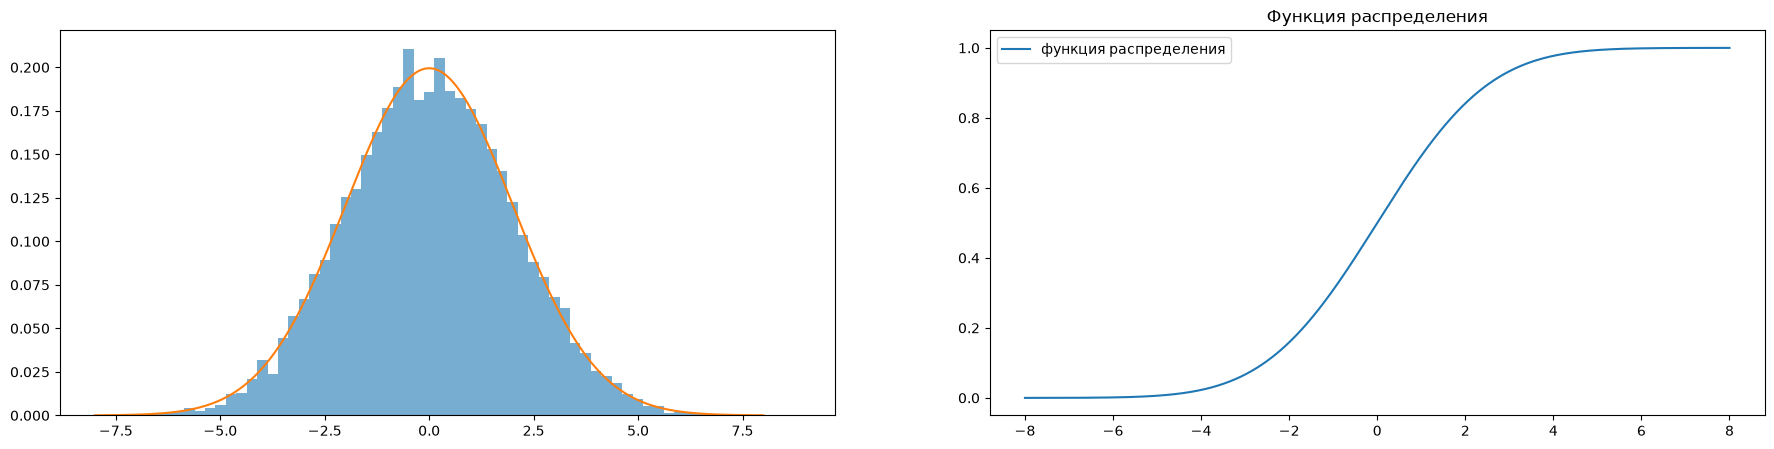

In [ ]:
norm_distribution = norm(loc=0, scale=2)
x = numpy.linspace(-8, 8, 1000)
pdf = norm_distribution.pdf(x)
cdf = norm_distribution.cdf(x)
sample = norm_distribution.rvs(size=10000)

pyplot.figure(figsize=(22, 5))
pyplot.subplot(1, 2, 1)
pyplot.hist(
    sample, bins="auto", density=True, alpha=0.6, label="сгенерированные значения"
)  # rvs
pyplot.plot(x, pdf, label="плотность распределения")

pyplot.subplot(1, 2, 2)
pyplot.title("Функция распределения", fontsize=12)
pyplot.plot(x, cdf, label="функция распределения")

pyplot.legend()
pyplot.show()

### Свойства нормального распределения

- $\xi_1 \sim \mathcal{N}(\mu_1, \sigma_1^2),\ \xi_2 \sim \mathcal{N}(\mu_2, \sigma_2^2) \Rightarrow \xi_1 + \xi_2 \sim \mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$, [док-во](https://en.wikipedia.org/wiki/Sum_of_normally_distributed_random_variables#:~:text=This%20means%20that%20the%20sum,squares%20of%20the%20standard%20deviations)
- $a \xi_1 \sim \mathcal{N}(a\mu_1, a^2\sigma_1^2)$

Покажем корректность этих формул на практике:

Сначала проверим на примере формулу 1:

In [ ]:
# примеры
first_mean = 3
first_var = 4

second_mean = -1
second_var = 2

first_dist = norm(loc=first_mean, scale=numpy.sqrt(first_var))
second_dist = norm(loc=second_mean, scale=numpy.sqrt(second_var))
# Важно scale=numpy.sqrt(first_var + second_var)
checking_sum_distr = norm(
    loc=first_mean + second_mean, scale=numpy.sqrt(first_var + second_var)
)

1. Нагенерируем выборку из 1 и 2 распределений и просуммируем их.
2. Далее, построим эмпирическую плотность распределения и сравним ее с настоящей на графике.

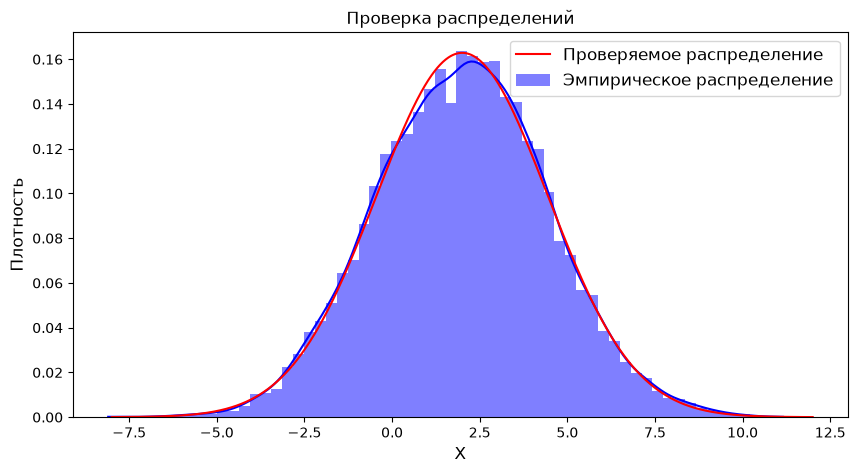

In [98]:
first_sample = first_dist.rvs(10000)
second_sample = second_dist.rvs(10000)
sum_sample = first_sample + second_sample

x = numpy.linspace(-8, 12, 1000)

pyplot.figure(figsize=(10, 5))
pyplot.title("Проверка распределений", fontsize=12)
seaborn.histplot(
    sum_sample,
    stat="density",
    kde=True,
    label="Эмпирическое распределение",
    color="blue",
    edgecolor=None
)
pyplot.plot(
    x, checking_sum_distr.pdf(x), label="Проверяемое распределение", color="red"
)
pyplot.legend(fontsize=12)
pyplot.xlabel("X", fontsize=12)
pyplot.ylabel("Плотность", fontsize=12)
pyplot.show()

In [58]:
a = 5
mean = 3
var = 4
dist = norm(loc=mean, scale=numpy.sqrt(var))
check_multiple_a_and_dist = norm(loc=a * mean, scale=numpy.sqrt(a**2 * var))

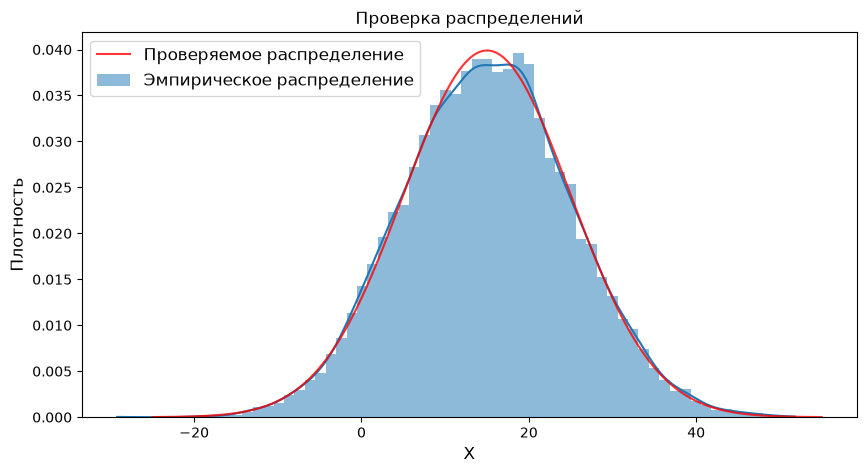

In [97]:
sample = dist.rvs(10000)
multiple_sample = a * sample

x_min = a * mean - 4 * numpy.sqrt(a**2 * var)
x_max = a * mean + 4 * numpy.sqrt(a**2 * var)
x = numpy.linspace(x_min, x_max, 1000)

pyplot.figure(figsize=(10, 5))
pyplot.title("Проверка распределений", fontsize=12)
seaborn.histplot(
    multiple_sample, stat="density", kde=True, label="Эмпирическое распределение", edgecolor=None
)
pyplot.plot(
    x,
    check_multiple_a_and_dist.pdf(x),
    label="Проверяемое распределение",
    color="red",
    alpha=0.8,
)
pyplot.legend(fontsize=12)
pyplot.xlabel("X", fontsize=12)
pyplot.ylabel("Плотность", fontsize=12)
pyplot.show()

## ЦПТ
Вспомним теорему, которая является основополагающей теоремой для всех критериев.

**Центральная предельная теорема**

*Формулировка теоремы*

Пусть $\xi_1, ..., \xi_n$ &mdash; **независимо** одинаково распределенные случайные величины, у которых сущестуют мат. ожидание и дисперсия: $E [\xi_i] = \mu < \infty$ и $Var[\xi_i] = \sigma^2 < \infty$. тогда $\sqrt{n}\dfrac{\overline \xi - \mu}{\sqrt{\sigma^2}}$ [сходится по распределению](https://en.wikipedia.org/wiki/Convergence_in_distribution) к $\mathcal{N}(0, 1)$.
Можно также написать эквивалентное выражение:
$$
\dfrac{\xi_1 + ... + \xi_n - n\mu}{\sqrt{\sigma^2}\sqrt{n}}
$$.
*Что это значит на практике*

Если случайные величины в эксперименте **независимы и одинаково распределены** и ваша выборка **достаточно большая**, то вы можете полагать, что 
$$
\sqrt{n}\dfrac{\overline \xi - \mu}{\sqrt{\sigma^2}} \sim \mathcal{N}(0, 1),
$$

где $\mu, \sigma^2$ &mdash; мат. ожидание и дисперсия одного элемента выборки.


*Дополнение*

Случайные величины могут быть слабо зависимы друг от друга и слегка по-разному распределены. Центральная предельная теорема все еще будет [верна](https://en.wikipedia.org/wiki/Stable_distribution#A_generalized_central_limit_theorem).


Несмотря на ослабление условий, **всегда держите в голове условия применимости ЦПТ**: забыв про них и не проверив свой критерий, вы можете некорректно проанализировать свой AB-тест.

### Визуализация ЦПТ

Визуализация теоремы: посмотрим на распределение средних значений в разных выборках. Как мы это сделаем?

- Чтобы посмотреть, что некоторая случайная величина из нормального распределения, нам нужна выборка этих случайных величин.
- В данном случае нам нужна выборка статистик из ЦПТ. Поэтому нам нужно нагенерировать N выборок по M элементов в каждой.
    - По каждой выборке надо посчитать нормированное среднее по M элементам.
    - В итоге мы получим выборку из N элементов.
    - Она и должна быть из нормального распределения.

In [89]:
def visualize_CLT(sample_generator, expected_value, variance):
    """
    Функция-визуализатор ЦПТ. Строит:
        - гисторгамму статистики ЦПТ,
        - эмпирическую плотность,
        - плотность нормального распределения.
    Параметры:
        - sample_generator: функция-генератор выборки. Не принимает ничего на вход
        - expected_value: мат. ожидание выборки
        - variance: дисперсия выборки
    """

    numpy.random.seed(42)
    N = 5000
    clt_sample = []
    for _ in range(N):
        sample = sample_generator()

        sample_size = len(sample)
        statistic = (
            numpy.sqrt(sample_size)
            * (numpy.mean(sample) - expected_value)
            / numpy.sqrt(variance)
        )
        clt_sample.append(statistic)

    x = numpy.linspace(-4, 4, 1000)
    pyplot.figure(figsize=(10, 5))
    pyplot.title("Распределение средних значений", fontsize=12)
    seaborn.histplot(clt_sample, stat='density', kde=True, bins=50, edgecolor=None, alpha=0.6, label='Эмпирическое распределение')
    pyplot.plot(x, norm(0,1).pdf(x), color='lightgreen', label=r"$\mathcal{N}(0, 1)$")
    pyplot.legend()
    pyplot.xlabel("X", fontsize=12)
    pyplot.ylabel("Плотность", fontsize=12)
    pyplot.show()

Проверим биномиальное распределение

In [90]:
def binom_generator(p, n, size):
    return binom(p=p, n=n).rvs(size)

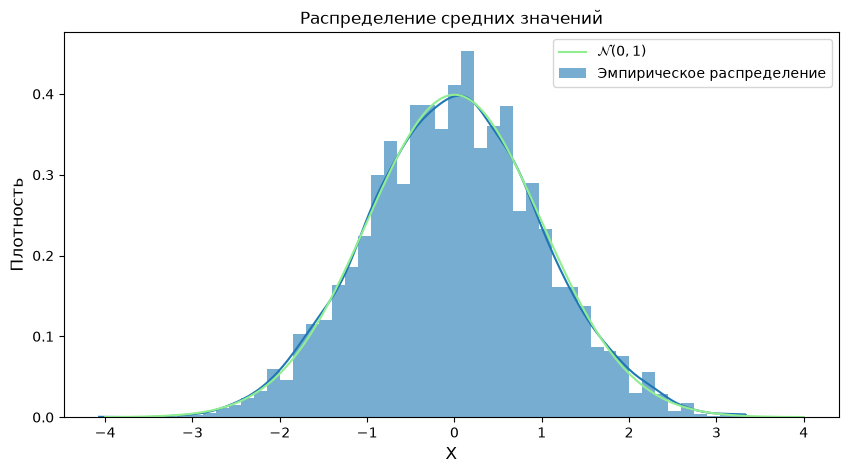

In [91]:
p = 0.01
n = 20
size = 5000

visualize_CLT(
    lambda: binom_generator(p, n, size), expected_value=n * p, variance=n * p * (1 - p)
)

Эмпирическая плотность "почти" совпала с истинной. А что если уменьшить выборку, по которой считается среднее?

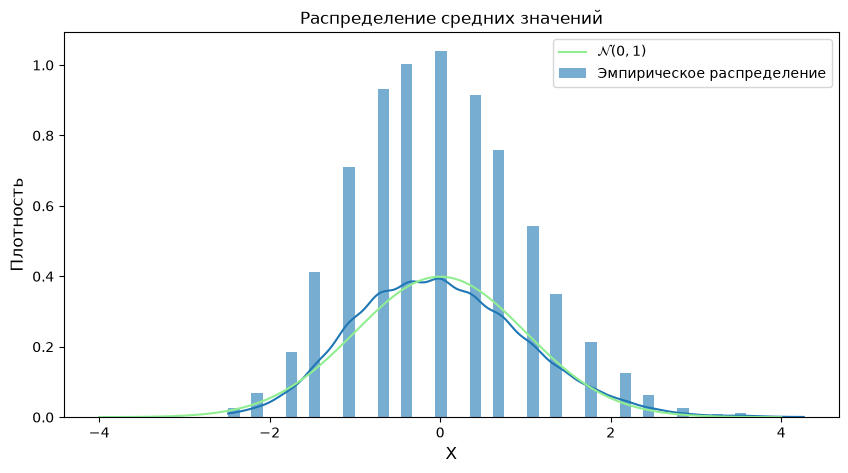

In [92]:
p = 0.01
n = 20
size = 40

visualize_CLT(lambda: binom_generator(p, n, size),
              expected_value = p * n,
              variance = n * p * (1 - p)
             )

Стало сильно хуже: появились пробелы в распределении, да и сама эмпирическая функция распределения слегка "сдвинута". Так что наш эксперимент подтвердил важность размера выборки для корректной работы ЦПТ.


Теперь давайте посмотрим на другое распределение: [экспоненциальное](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html).

In [95]:
def expon_generator(expected_value, size):
    return expon(scale=expected_value).rvs(size)

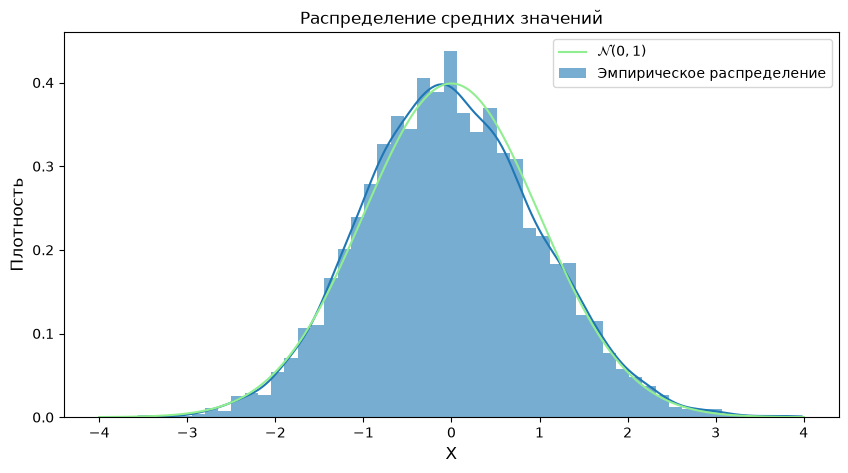

In [96]:
expected_value = 24
size = 400

visualize_CLT(lambda: expon_generator(expected_value, size),
              expected_value=expected_value, variance=expected_value ** 2)

Тут все хорошо работает

**Эквивалентные формулировки ЦПТ**

$$\begin{align}
\sqrt{n}\dfrac{\overline \xi - \mu}{\sqrt{\sigma^2}} &\sim \mathcal{N}(0, 1) \stackrel{св. 2}{\Leftrightarrow}\\
\overline \xi - \mu &\sim \mathcal{N}\left(0, \dfrac{\sigma^2}{n} \right) \Leftrightarrow\\
\dfrac{\underset{i=1}{\overset{n}{\sum}} \xi_i}{n} &\sim \mathcal{N}\left(\mu, \dfrac{\sigma^2}{n} \right) \Leftrightarrow\\
\underset{i=1}{\overset{n}{\sum}} \xi_i &\sim \mathcal{N}\left(n \cdot \mu, n \cdot \sigma^2 \right)
\end{align}$$

А значит сумма случайных величин также распределена нормально